<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_12_4_gradient_explain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T81-558: Applications of Deep Neural Networks
**Module 12: Explainability**  

* Instructor: [Jeff Heaton](https://sites.washu.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.washu.edu/index.html)
* For more information visit the [class website](https://sites.washu.edu/jeffheaton/t81-558/).

# Module 12 Material

* Part 12.1: What is Explainability [[Notebook]](t81_558_class_12_1_explainability.ipynb)
* Part 12.2: Feature Importance [[Notebook]](t81_558_class_12_2_feature_importance.ipynb)
* Part 12.3: Visualization for Computer Vision [[Notebook]](t81_558_class_12_3_vision_viz.ipynb)
* **Part 12.4: Gradient-Based Explanations** [[Notebook]](t81_558_class_12_4_gradient_explain.ipynb)
* Part 12.5: Limitations of Explainability [[Notebook]](t81_558_class_12_5_limitations.ipynb)

# Google CoLab Instructions

The following code checks that Google CoLab is running and sets up the correct hardware settings for PyTorch.

In [1]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

# Make use of a GPU or MPS (Apple) if one is available.  (see module 2.5)
import torch
has_mps = torch.backends.mps.is_built()
device = "mps" if has_mps else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Note: not using Google CoLab


Using device: mps


# Part 12.4: Gradient-Based Explanations

The occlusion method from the previous section is intuitive but expensive, requiring a separate forward pass for every patch position. Gradient-based explanations achieve a similar goal, a map of what mattered for the prediction, from the information the network already produces during backpropagation. The insight is simple: the gradient of a class score with respect to the input tells us how sensitive that score is to each pixel. A pixel whose small change would strongly alter the score is, by definition, important to the prediction. One backward pass yields this sensitivity for every pixel at once.

This section covers the two most influential gradient-based techniques. **Vanilla gradient saliency** takes the gradient of the class score directly with respect to the input pixels, producing a fine-grained but noisy importance map. **Grad-CAM** instead uses the gradients flowing into the last convolutional layer to weight that layer's feature maps, producing a coarse but clean and class-discriminative localization. The two are complementary: saliency is detailed but jittery, while Grad-CAM is smooth but low-resolution.

As before, we work with a pretrained ResNet-18 and the same sample image, so that the explanations here can be compared directly against the occlusion map from the previous section.

## Setup

We reload the pretrained classifier and the test image. Because gradient methods require backpropagation through the network, we will not wrap the forward passes in `torch.no_grad()` this time; instead we deliberately track gradients, in one case all the way back to the input pixels.

In [2]:
import io
import urllib.request
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models
from torchvision.models import ResNet18_Weights

weights = ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights).eval()
categories = weights.meta["categories"]
preprocess = weights.transforms()

url = "https://github.com/pytorch/hub/raw/master/images/dog.jpg"
img = Image.open(io.BytesIO(urllib.request.urlopen(url).read())).convert("RGB")
x = preprocess(img).unsqueeze(0)

with torch.no_grad():
    target = model(x).argmax(1).item()
print("Explaining prediction:", categories[target])

Explaining prediction: Samoyed


## Vanilla Gradient Saliency

The original saliency method, introduced by Simonyan and colleagues, computes the gradient of the predicted class score with respect to each input pixel. We mark the input as requiring gradients, run it forward to get the class score, and call `backward()` on that score. The resulting gradient has the same shape as the image; taking the maximum absolute value across the three color channels collapses it to a single importance value per pixel. Bright pixels in the map are those the model is most sensitive to.

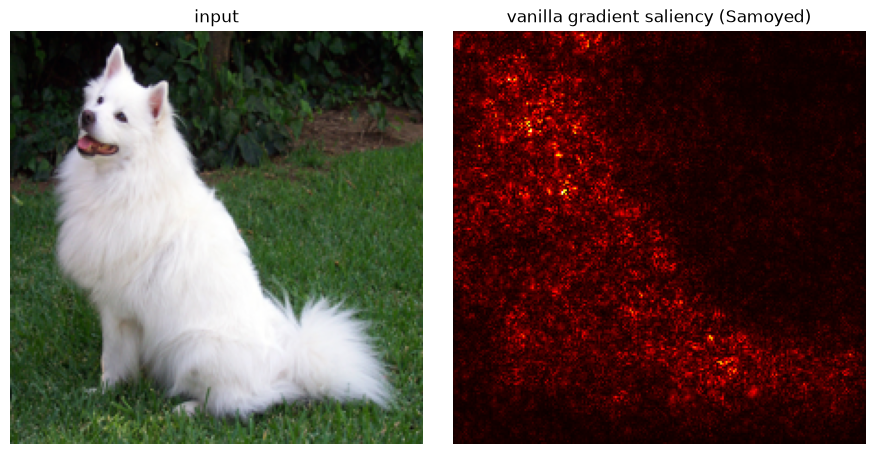

In [3]:
# Track gradients back to the input pixels.
x_grad = preprocess(img).unsqueeze(0).requires_grad_(True)

score = model(x_grad)[0, target]
model.zero_grad()
score.backward()

# Importance per pixel: max absolute gradient across the color channels.
saliency = x_grad.grad.abs().amax(dim=1)[0].numpy()

fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
ax[0].imshow(img.resize((224, 224)))
ax[0].axis("off")
ax[0].set_title("input")
ax[1].imshow(saliency, cmap="hot")
ax[1].axis("off")
ax[1].set_title(f"vanilla gradient saliency ({categories[target]})")
plt.tight_layout()
plt.show()

The saliency map picks out the animal, with the brightest pixels clustered along its edges and distinctive features, where a small change would most affect the score. The map is detailed at the pixel level but visibly noisy, scattered with speckle even in unimportant regions. This graininess is the well-known weakness of vanilla gradients, and methods such as SmoothGrad and Integrated Gradients were developed largely to clean it up. Rather than pursue those refinements, we turn to a different and very widely used approach that trades pixel resolution for a much cleaner signal.

## Grad-CAM

Grad-CAM (Gradient-weighted Class Activation Mapping) explains a prediction using the last convolutional layer rather than the input pixels. The intuition is that the final convolutional feature maps still carry spatial information while also encoding high-level concepts. Grad-CAM asks how important each of those feature-map channels is to the target class, by averaging the gradient of the class score over each channel, and then forms a weighted sum of the feature maps using those importances. A ReLU keeps only the regions that support the class.

Implementing this requires access to both the activations of the last convolutional block and the gradients flowing back into it. We capture the activations with a forward hook and the gradients with a full backward hook, then combine them. Because the resulting map is only 7-by-7, the spatial resolution of ResNet's final block, we upsample it to the image size for display.

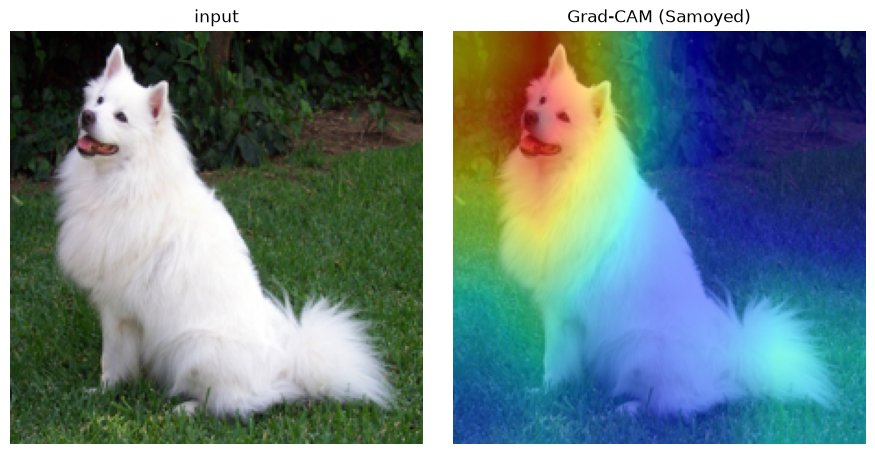

In [4]:
# Capture the last conv block's activations (forward) and gradients (backward).
store = {}
def fwd_hook(module, inputs, output):
    store["activation"] = output.detach()
def bwd_hook(module, grad_in, grad_out):
    store["gradient"] = grad_out[0].detach()

f_handle = model.layer4.register_forward_hook(fwd_hook)
b_handle = model.layer4.register_full_backward_hook(bwd_hook)

score = model(x)[0, target]
model.zero_grad()
score.backward()
f_handle.remove()
b_handle.remove()

A = store["activation"][0]              # (512, 7, 7) feature maps
grad = store["gradient"][0]            # (512, 7, 7) gradients
channel_weights = grad.mean(dim=(1, 2))               # importance per channel
cam = F.relu((channel_weights[:, None, None] * A).sum(0))   # (7, 7)
cam = cam / cam.max()

# Upsample the coarse 7x7 map to the full image size.
cam = F.interpolate(cam[None, None], size=(224, 224),
                    mode="bilinear", align_corners=False)[0, 0].numpy()

fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
ax[0].imshow(img.resize((224, 224)))
ax[0].axis("off")
ax[0].set_title("input")
ax[1].imshow(img.resize((224, 224)))
ax[1].imshow(cam, cmap="jet", alpha=0.5)
ax[1].axis("off")
ax[1].set_title(f"Grad-CAM ({categories[target]})")
plt.tight_layout()
plt.show()

Overlaid on the image, the Grad-CAM heatmap forms a clean, coherent blob over the animal, sharply localizing the region responsible for the prediction without the pixel-level noise of the saliency map. This agrees with the occlusion result from the previous section, but Grad-CAM obtained it from a single backward pass rather than a hundred forward passes. Its coarseness, inherited from the 7-by-7 feature grid, is the price for that clean signal.

The three views we now have of the same prediction, occlusion, vanilla saliency, and Grad-CAM, mostly agree that the model is looking at the animal, and that agreement is genuinely reassuring. But agreement is not guaranteed, and none of these maps is the literal truth about the model's reasoning. Each is an approximation with characteristic failure modes. The final section of this module, [Limitations of Explainability](t81_558_class_12_5_limitations.ipynb), examines when and why these explanations can mislead.